# Simple Linear Regression

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [240]:
# load the dataset

df = pd.read_csv('height_weight.csv')
df

,Height,Weight
0,178,74.59
1,191,81.57
2,168,73.98
3,154,57.34
4,182,82.09
...,...,...
995,143,39.08
996,140,44.01
997,188,80.88
998,179,80.04


In [241]:
df.head()
df2 = df.head(50)
df2

,Height,Weight
0,178,74.59
1,191,81.57
2,168,73.98
3,154,57.34
4,182,82.09
5,147,50.05
6,160,64.07
7,178,81.31
8,197,74.86
9,158,57.32


Text(0, 0.5, 'Height')

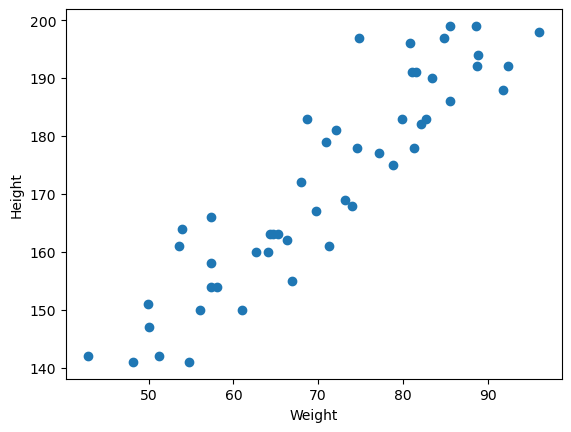

In [242]:
plt.scatter(df2['Weight'], df2['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [243]:
# EDA, FE
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  1000 non-null   int64  
 1   Weight  1000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


In [244]:
df.describe()

,Height,Weight
count,1000.000000,1000.000000
mean,170.200000,69.525440
std,17.372905,13.224663
min,140.000000,38.660000
25%,156.000000,59.197500
50%,171.000000,70.115000
75%,186.000000,80.095000
max,199.000000,101.810000


In [245]:
df.isna().sum()

Height    0
Weight    0
dtype: int64

In [246]:
df.head()

,Height,Weight
0,178,74.59
1,191,81.57
2,168,73.98
3,154,57.34
4,182,82.09


In [247]:
# Divide the dataset into independent and denpendent feature
x=df2[['Weight']]
y = df2['Height']

y

0     178
1     191
2     168
3     154
4     182
5     147
6     160
7     178
8     197
9     158
10    162
11    150
12    150
13    163
14    192
15    175
16    179
17    163
18    142
19    161
20    192
21    141
22    163
23    183
24    169
25    177
26    141
27    199
28    160
29    172
30    151
31    197
32    161
33    183
34    164
35    188
36    166
37    198
38    181
39    167
40    199
41    155
42    154
43    186
44    190
45    183
46    194
47    191
48    196
49    142
Name: Height, dtype: int64

In [248]:
x.shape,y.shape

((50, 1), (50,))

In [249]:
# Devide  the dataset into the train and test
from  sklearn.model_selection import train_test_split


In [250]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size= 0.2,random_state= 42)

In [251]:
X_train.shape, X_test.shape

((40, 1), (10, 1))

In [252]:
y_train.shape, y_test.shape

((40,), (10,))

In [253]:
X_train

,Weight
12,56.02
4,82.09
37,96.10
8,74.86
3,57.34
6,64.07
41,66.87
46,88.88
47,81.06
15,78.87


In [254]:
X_test

,Weight
13,64.35
39,69.71
30,49.96
45,79.86
17,64.68
48,80.80
26,54.76
25,77.13
32,53.60
19,71.29


In [255]:
y_test

13    163
39    167
30    151
45    183
17    163
48    196
26    141
25    177
32    161
19    161
Name: Height, dtype: int64

In [256]:
y_train

12    150
4     182
37    198
8     197
3     154
6     160
41    155
46    194
47    191
15    175
9     158
16    179
24    169
34    164
31    197
0     178
44    190
27    199
33    183
5     147
29    172
11    150
36    166
1     191
21    141
2     168
43    186
35    188
23    183
40    199
10    162
22    163
18    142
49    142
20    192
7     178
42    154
14    192
28    160
38    181
Name: Height, dtype: int64

In [257]:
# Standard Scaling on the train and test Data
from sklearn.preprocessing import StandardScaler

In [258]:
scaler = StandardScaler()

In [259]:
X_train = scaler.fit_transform(X_train)
X_train

array([[-1.13926162],
       [ 0.75384971],
       [ 1.77120643],
       [ 0.22883265],
       [-1.04340788],
       [-0.55469905],
       [-0.35137294],
       [ 1.24691553],
       [ 0.67905475],
       [ 0.52002468],
       [-1.04486021],
       [-0.05437158],
       [ 0.10393232],
       [-1.29103004],
       [ 0.95717582],
       [ 0.2092262 ],
       [ 0.84752496],
       [ 1.22513059],
       [ 0.79596726],
       [-1.57278193],
       [-0.27004249],
       [-0.77327462],
       [-1.04050322],
       [ 0.71608915],
       [-1.70857473],
       [ 0.16493015],
       [ 1.00655502],
       [ 1.45605096],
       [-0.21993713],
       [ 1.00437653],
       [-0.38768117],
       [-0.47264244],
       [-1.48927299],
       [-2.09271584],
       [ 1.23602306],
       [ 0.69720887],
       [-0.99402868],
       [ 1.50615632],
       [-0.6585406 ],
       [ 0.03276818]])

In [260]:
X_test = scaler.transform(X_test)
X_test

array([[-0.53436644],
       [-0.14514217],
       [-1.57931741],
       [ 0.59191499],
       [-0.510403  ],
       [ 0.66017447],
       [-1.23075837],
       [ 0.39367203],
       [-1.31499347],
       [-0.03040815]])

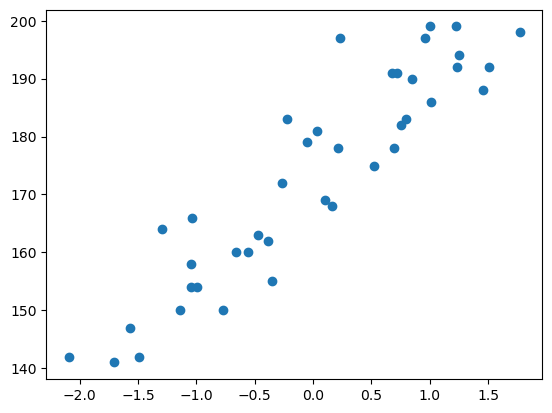

In [261]:
plt.scatter(X_train, y_train)

In [262]:
# Training the model
from sklearn.linear_model  import LinearRegression

In [263]:
regressor =LinearRegression()

In [264]:
# Training the Dataset

regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [265]:
regressor.intercept_

np.float64(173.25)

In [266]:
regressor.coef_

array([16.38747185])

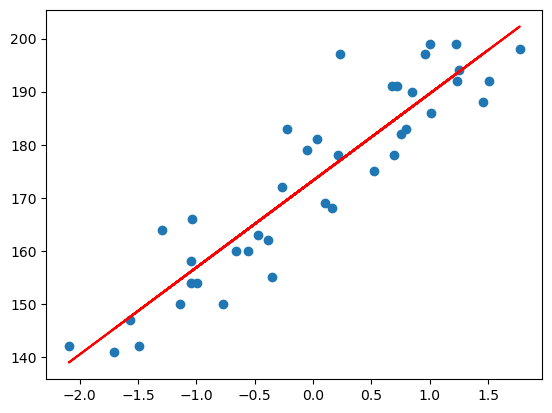

In [267]:
plt.scatter(X_train, y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

# Prediction Of Train Data 
1. predict height output = intercept + coef_(weights)
2. y_pred_train = 169.41875 + (-1.79716914)(X_train)

# Prediction Of Test Data 
1. predict height output = intercept + coef_(weights)
2. y_pred_test = 169.41875 + (-1.79716914)(X_test)

In [268]:
#  Prediction for test data
y_predict_test =regressor.predict(X_test)
y_predict_test

array([164.49308507, 170.87148684, 147.36898033, 182.94999019,
       164.88578518, 184.0685905 , 153.08098191, 179.70128929,
       151.70058153, 172.75168736])

In [269]:
y_test

13    163
39    167
30    151
45    183
17    163
48    196
26    141
25    177
32    161
19    161
Name: Height, dtype: int64

# MAE , MSE , RMSE


In [270]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [271]:
mse = mean_squared_error(y_test, y_predict_test)
mae = mean_absolute_error(y_test, y_predict_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

55.414766420533944
5.869617311463594
7.444109511589277


# Accurcy - of the model - R squared , Adjusted R squared

## R Square
### R ^ 2 = 1.SSR/SST
##### R^2 = Accuracy of the model
##### SSR = sum of squares of residuals
##### SST = total sum of square

In [272]:
from sklearn.metrics import r2_score

In [273]:
score =r2_score(y_test,y_predict_test)

In [274]:
score

0.7512913853932321

# Adjusted r squared

**Adjusted R2 = 1 - [(1-R2)*(n-1)/(n-k-1)]**

###### where:
- R2: The R2 of the model
- n : The number of observations
- k : The number of predictor variables

In [276]:
1 - (1- score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7202028085673862